# TD Learning with ε-Greedy Policy in Gridworld
This notebook demonstrates Temporal Difference (TD) learning with an ε-greedy policy on a simple 4x4 Gridworld. The agent learns state values by interacting with the environment, updating its value estimates after each episode using the TD(0) method. Negative and positive rewards are placed in the grid, and the agent's policy balances exploration and exploitation.

## Import Required Libraries
Import the necessary libraries for numerical computation, random number generation, and plotting.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

## Initialize Rewards, State Values, and Hyperparameters
Set up the reward structure for the grid, initialize the state values, and define key hyperparameters such as the learning rate (alpha) and exploration rate (epsilon).

In [2]:
rewards = np.zeros(16)
rewards[3] = 10
rewards[2] = -1
rewards[11] = -1
rewards[10] = -1

terminal_state = 3
state_values = np.zeros(16)
alpha = 0.02
epsilon = 0.3

score_log = []

## Visualize Reward Structure
Display the reward values for each cell in the 4x4 grid to understand the environment layout.

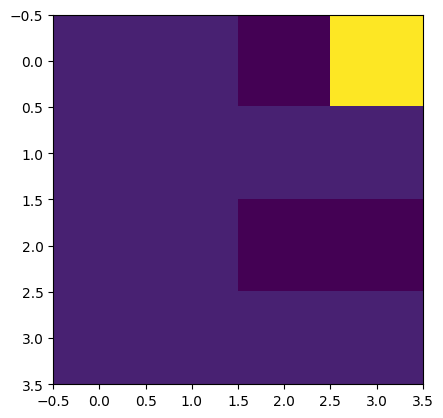

In [3]:
plt.imshow(rewards.reshape(4, 4))

## Load State Transition Table
Load the state transition table from a CSV file. This table defines the possible next states for each action in every state.

In [4]:
state_transition_table = np.genfromtxt("state_transitions.csv", delimiter=",").astype(int)

## Define TD(0) Update Function
Implement the TD(0) update rule, which updates state values based on the observed rewards and the estimated value of the next state.

In [5]:
def TD_update(next_val, values, rewards, states):
    gamma = 0.9
    next_val = next_val
    #fixed bug in code here
    new_values = np.zeros(16) + values
    for i in reversed(range(len(rewards))):
        new_values[states[i]] = values[states[i]] + alpha * (rewards[i] + gamma * next_val - values[states[i]])
        next_val = values[states[i]]
    return new_values

## Define Agent Testing Function
Create a function to test the agent's current policy by running it from the start state to the terminal state, returning the total reward and the path taken.

In [6]:
def test_agent():
    state = 12
    steps = 0
    total_rewards = 0
    states_log = []
    while (not(state == terminal_state)) and steps<100:
        states_log.append(state)
        action = np.argmax(state_values[state_transition_table[state]])
        state = state_transition_table[state, action]
        total_rewards += rewards[state]
        steps += 1
    states_log.append(state)
    return total_rewards, states_log

## Train the Agent with TD(0) and ε-Greedy Policy
Run multiple episodes where the agent explores the environment, collects rewards, and updates its value estimates using the TD(0) update rule. The ε-greedy policy balances exploration and exploitation.

In [7]:
for _ in range(300):
    state = 12
    state_log = []
    reward_log = []
    done = False
    steps = 0

    while (not(state == terminal_state)) and steps<100:
        state_log.append(state)
        reward_log.append(rewards[state])
        
        z = random.random()
        if z >=epsilon:
            action = np.argmax(state_values[state_transition_table[state]])
        else:
            action = random.randint(0,3)
            
        state = state_transition_table[state, action]

        steps += 1
        
    state_log.append(state)
    reward_log.append(rewards[state])
    next_val = state_values[state]
    state_values = TD_update(next_val, state_values, reward_log, state_log)
    
    score_log.append(test_agent()[0])

## Visualize Learned State Values
Display the learned value function for each state in the grid after training. Each cell shows the estimated value for that state.

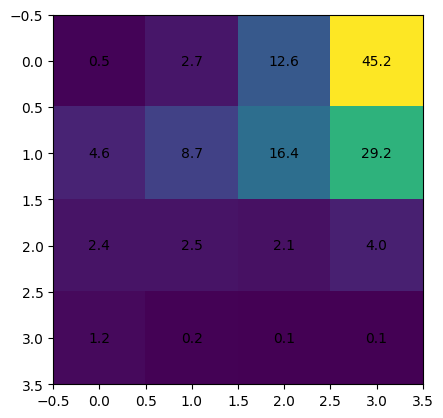

In [8]:
fig1, ax1= plt.subplots(1)
ax1.imshow(state_values.reshape(4, 4))

for (j,i), label in np.ndenumerate(state_values.reshape(4, 4).round(1)):
    ax1.text(i,j,label,ha='center',va='center')

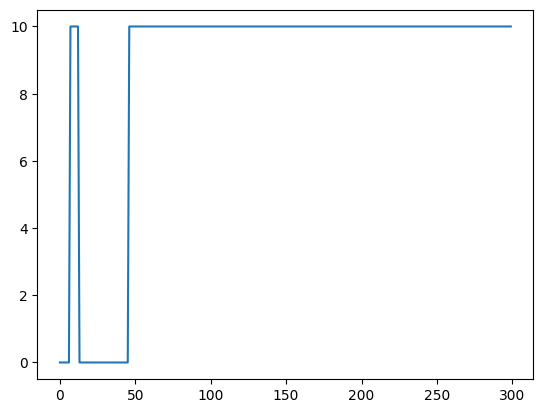

In [9]:
plt.plot(score_log)

## Visualize Agent's Final Path
Show the path taken by the trained agent from the start state to the terminal state, highlighting the states visited.

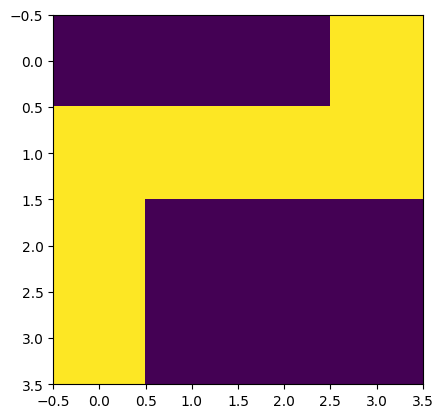

In [10]:
_, state_log = test_agent()
state_view = np.zeros(16)
state_view[state_log] = 1
plt.imshow(state_view.reshape(4,4))